<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
#urvey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Working copy
bubble_part = df[
    ["Age", "SOPartFreq", "JobSat"]
].copy()

# Convert Age to approximate numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": np.nan
}

bubble_part["AgeNumeric"] = bubble_part["Age"].map(age_mapping)

# Inspect participation categories first
print("SOPartFreq categories:")
print(bubble_part["SOPartFreq"].value_counts(dropna=False))

SOPartFreq categories:
SOPartFreq
Less than once per month or monthly                   24162
NaN                                                   20200
I have never participated in Q&A on Stack Overflow    11143
A few times per month or weekly                        6277
A few times per week                                   2278
Daily or almost daily                                   936
Multiple times per day                                  441
Name: count, dtype: int64


In [4]:
participation_mapping = {
    "I have never participated in Q&A on Stack Overflow": 0,
    "Less than once per month or monthly": 1,
    "A few times per month or weekly": 2,
    "A few times per week": 3,
    "Daily or almost daily": 4,
    "Multiple times per day": 5
}

Valid observations: 23349


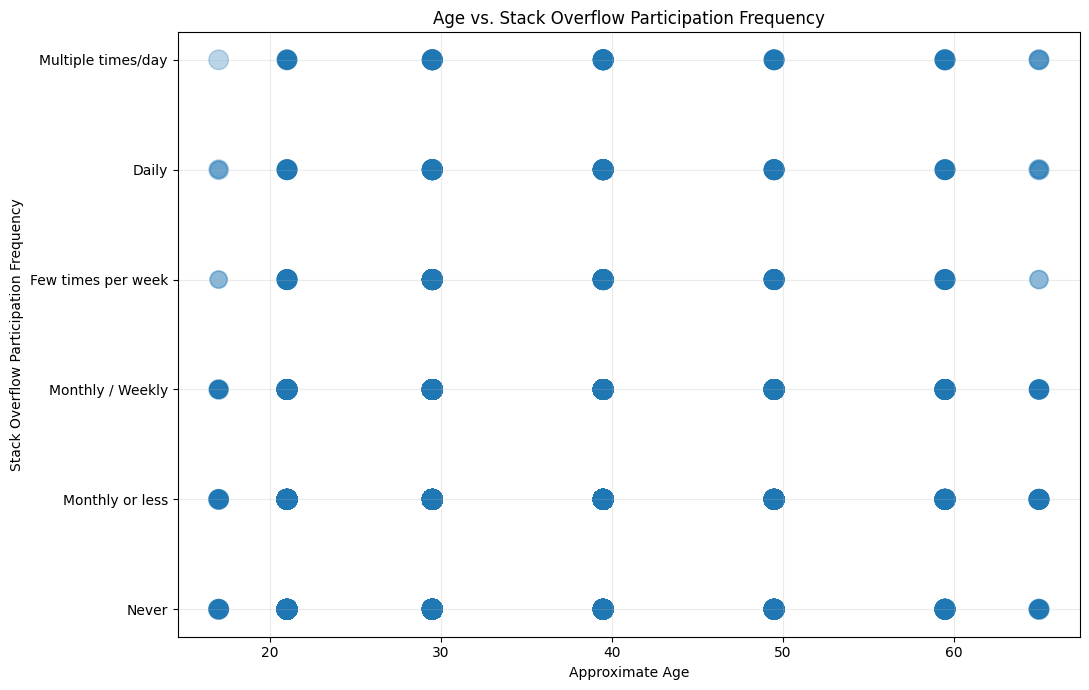

In [5]:
# Convert participation frequency to ordinal numeric values
bubble_part["ParticipationNumeric"] = (
    bubble_part["SOPartFreq"]
    .map(participation_mapping)
)

# Convert JobSat to numeric
bubble_part["JobSat"] = pd.to_numeric(
    bubble_part["JobSat"],
    errors="coerce"
)

# Keep only valid observations
plot_df = bubble_part.dropna(
    subset=["AgeNumeric", "ParticipationNumeric", "JobSat"]
)

print("Valid observations:", len(plot_df))

# Bubble size represents JobSat
bubble_sizes = (plot_df["JobSat"] + 1) * 18

plt.figure(figsize=(11, 7))

plt.scatter(
    plot_df["AgeNumeric"],
    plot_df["ParticipationNumeric"],
    s=bubble_sizes,
    alpha=0.30
)

plt.title("Age vs. Stack Overflow Participation Frequency")
plt.xlabel("Approximate Age")
plt.ylabel("Stack Overflow Participation Frequency")

# Restore readable category labels
plt.yticks(
    [0, 1, 2, 3, 4, 5],
    [
        "Never",
        "Monthly or less",
        "Monthly / Weekly",
        "Few times per week",
        "Daily",
        "Multiple times/day"
    ]
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Analysis – Age vs. Stack Overflow Participation Frequency

The bubble plot compares respondents' approximate age with their frequency of participation in Stack Overflow Q&A, while bubble size represents `JobSat`.

Participation occurs across **all age groups and all frequency levels**, from respondents who have never participated to those who participate multiple times per day. There is no clear monotonic pattern indicating that participation consistently increases or decreases with age.

The most important visual result is the substantial overlap between age groups. Respondents of similar ages can have very different participation behaviors, suggesting that **age alone is not a strong determinant of Stack Overflow participation frequency**.

Bubble sizes also do not reveal a strong systematic pattern across participation levels. Larger and smaller bubbles appear throughout the chart, suggesting that job satisfaction does not clearly increase or decrease with Stack Overflow participation based on this visualization alone.

A limitation of the chart is **overplotting**. Since both `Age` and `SOPartFreq` were transformed into discrete values, many respondents occupy exactly the same coordinates. Therefore, a single visible bubble may represent multiple overlapping observations, and the chart should not be interpreted as showing the number of respondents at each position.

Overall, the visualization suggests that participation behavior is heterogeneous across age groups and that neither age nor job satisfaction appears to independently explain how frequently respondents participate in Stack Overflow Q&A. Additional analysis using frequencies or percentages by age group would be useful to quantify these relationships more precisely.

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


Valid observations: 16067
Pearson correlation: 0.0484
99th percentile used only for visualization: $375,313.48


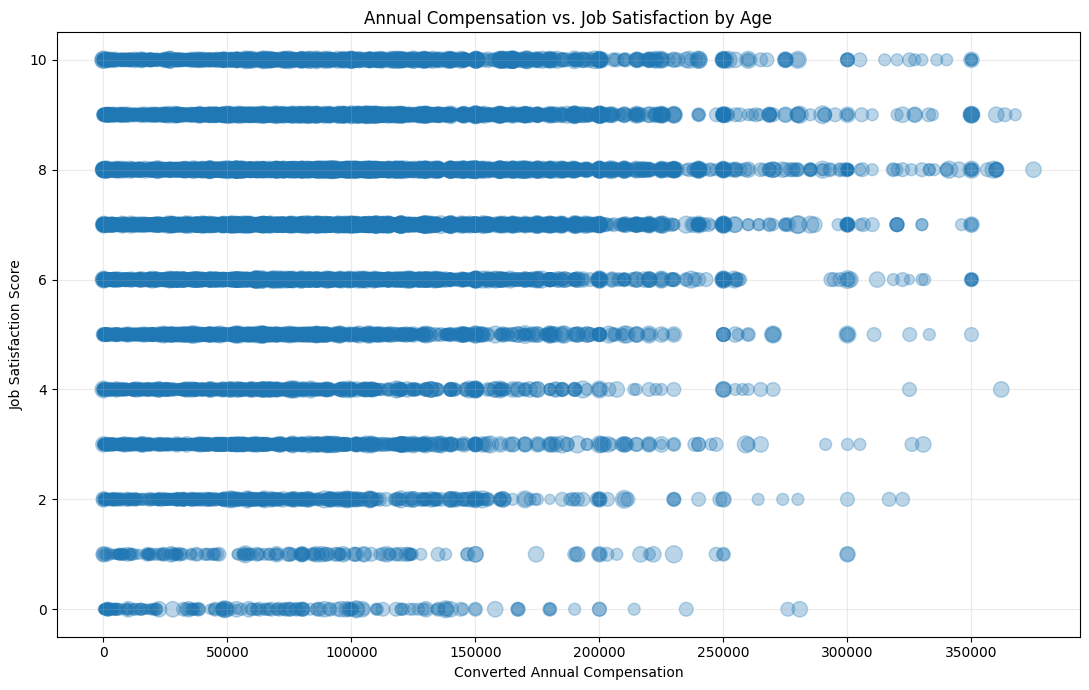

In [7]:
# Task 1.2 - Bubble Plot:
# Compensation vs. Job Satisfaction with Age as Bubble Size

bubble_comp = df[
    ["Age", "ConvertedCompYearly", "JobSat"]
].copy()

# Convert Age categories to approximate numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": np.nan
}

bubble_comp["AgeNumeric"] = bubble_comp["Age"].map(age_mapping)

# Convert variables to numeric
bubble_comp["ConvertedCompYearly"] = pd.to_numeric(
    bubble_comp["ConvertedCompYearly"],
    errors="coerce"
)

bubble_comp["JobSat"] = pd.to_numeric(
    bubble_comp["JobSat"],
    errors="coerce"
)

# Keep only valid observations for this analysis
bubble_comp = bubble_comp.dropna(
    subset=[
        "AgeNumeric",
        "ConvertedCompYearly",
        "JobSat"
    ]
)

# Keep meaningful compensation values
bubble_comp = bubble_comp[
    bubble_comp["ConvertedCompYearly"] >= 0
]

print("Valid observations:", len(bubble_comp))

# Correlation using all valid observations
correlation = bubble_comp["ConvertedCompYearly"].corr(
    bubble_comp["JobSat"]
)

print(f"Pearson correlation: {correlation:.4f}")

# Limit only the visualization to reduce the impact of extreme values
visual_limit = bubble_comp["ConvertedCompYearly"].quantile(0.99)

print(
    f"99th percentile used only for visualization: "
    f"${visual_limit:,.2f}"
)

plot_df = bubble_comp[
    bubble_comp["ConvertedCompYearly"] <= visual_limit
].copy()

# Bubble size represents approximate age
bubble_sizes = plot_df["AgeNumeric"] * 2.5

# Plot
plt.figure(figsize=(11, 7))

plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSat"],
    s=bubble_sizes,
    alpha=0.30
)

plt.title("Annual Compensation vs. Job Satisfaction by Age")
plt.xlabel("Converted Annual Compensation")
plt.ylabel("Job Satisfaction Score")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [8]:
# Task 2.1 - Technology Preferences by Age

tech_age = df[
    ["Age", "LanguageHaveWorkedWith"]
].copy()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": np.nan
}

tech_age["AgeNumeric"] = tech_age["Age"].map(age_mapping)

tech_age = tech_age.dropna(
    subset=["AgeNumeric", "LanguageHaveWorkedWith"]
)

# Separate multiple languages
tech_age["Language"] = (
    tech_age["LanguageHaveWorkedWith"]
    .str.split(";")
)

tech_age = tech_age.explode(
    "Language",
    ignore_index=True
)

tech_age["Language"] = tech_age["Language"].str.strip()

# Top 10 languages overall
top_languages = (
    tech_age["Language"]
    .value_counts()
    .head(10)
    .index
)

tech_age = tech_age[
    tech_age["Language"].isin(top_languages)
]

# Count respondents by Age + Language
tech_summary = (
    tech_age
    .groupby(["AgeNumeric", "Language"])
    .size()
    .reset_index(name="Frequency")
)

display(tech_summary.head(20))

,AgeNumeric,Language,Frequency
0,17.0,Bash/Shell (all shells),746
1,17.0,C,746
2,17.0,C#,650
3,17.0,C++,902
4,17.0,HTML/CSS,1560
5,17.0,Java,817
6,17.0,JavaScript,1538
7,17.0,Python,1656
8,17.0,SQL,656
9,17.0,TypeScript,718


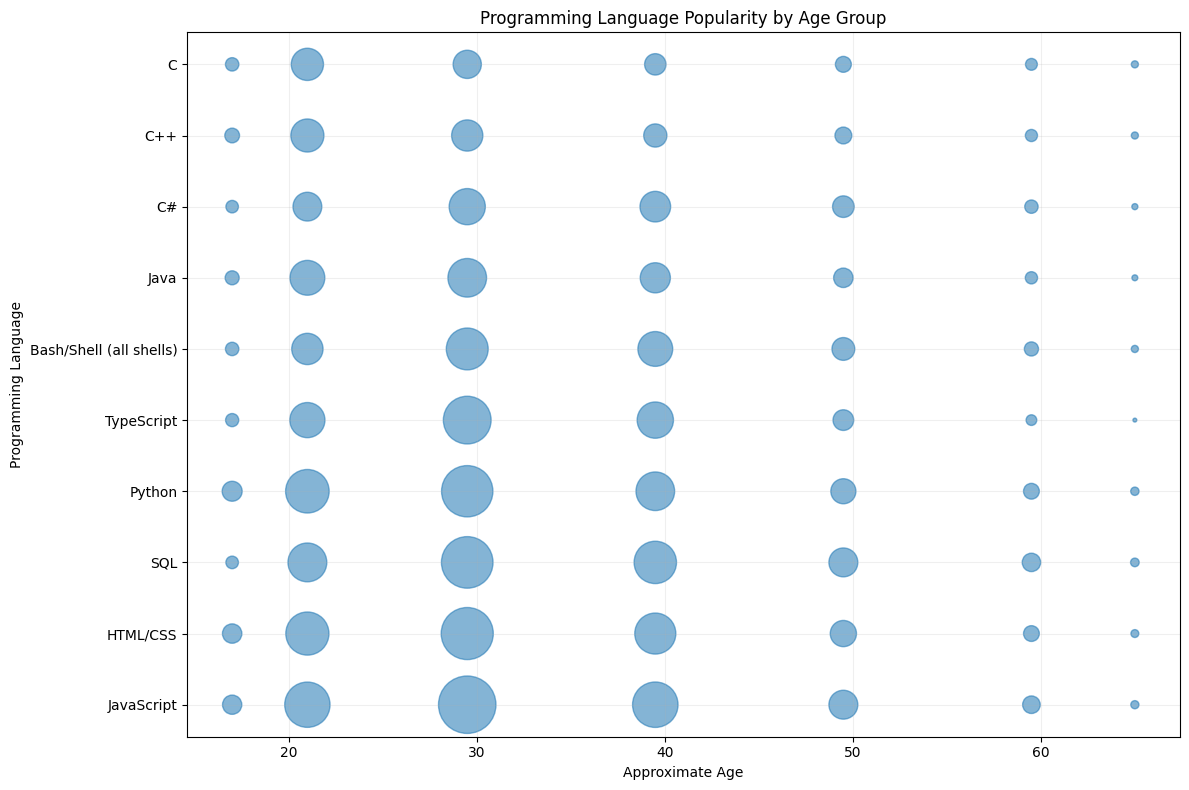

In [9]:
plt.figure(figsize=(12, 8))

# Convert language names to Y positions
language_order = list(top_languages)
language_positions = {
    language: i
    for i, language in enumerate(language_order)
}

y_values = tech_summary["Language"].map(language_positions)

# Scale bubble sizes
bubble_sizes = tech_summary["Frequency"] / 8

plt.scatter(
    tech_summary["AgeNumeric"],
    y_values,
    s=bubble_sizes,
    alpha=0.55
)

plt.yticks(
    range(len(language_order)),
    language_order
)

plt.title("Programming Language Popularity by Age Group")
plt.xlabel("Approximate Age")
plt.ylabel("Programming Language")

plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [10]:
# Task 2.2 - Preferred Databases vs Job Satisfaction

db_sat = df[
    ["DatabaseWantToWorkWith", "JobSat"]
].copy()

db_sat["JobSat"] = pd.to_numeric(
    db_sat["JobSat"],
    errors="coerce"
)

db_sat = db_sat.dropna(
    subset=["DatabaseWantToWorkWith", "JobSat"]
)

# Separate multiple database selections
db_sat["Database"] = (
    db_sat["DatabaseWantToWorkWith"]
    .str.split(";")
)

db_sat = db_sat.explode(
    "Database",
    ignore_index=True
)

db_sat["Database"] = db_sat["Database"].str.strip()

# Top 10 preferred databases
top_databases = (
    db_sat["Database"]
    .value_counts()
    .head(10)
    .index
)

db_top = db_sat[
    db_sat["Database"].isin(top_databases)
]

# Aggregate
database_summary = (
    db_top
    .groupby("Database")
    .agg(
        Respondents=("JobSat", "count"),
        MedianJobSat=("JobSat", "median"),
        MeanJobSat=("JobSat", "mean")
    )
    .sort_values("Respondents", ascending=False)
)

display(database_summary.round(2))

,Respondents,MedianJobSat,MeanJobSat
Database,,,
PostgreSQL,13261,7.0,6.94
SQLite,6859,7.0,6.92
Redis,6436,7.0,6.98
MySQL,5973,7.0,6.98
MongoDB,5655,7.0,6.90
Microsoft SQL Server,4615,7.0,7.07
Elasticsearch,3873,7.0,7.00
MariaDB,3101,7.0,6.99
Dynamodb,2150,7.0,7.08


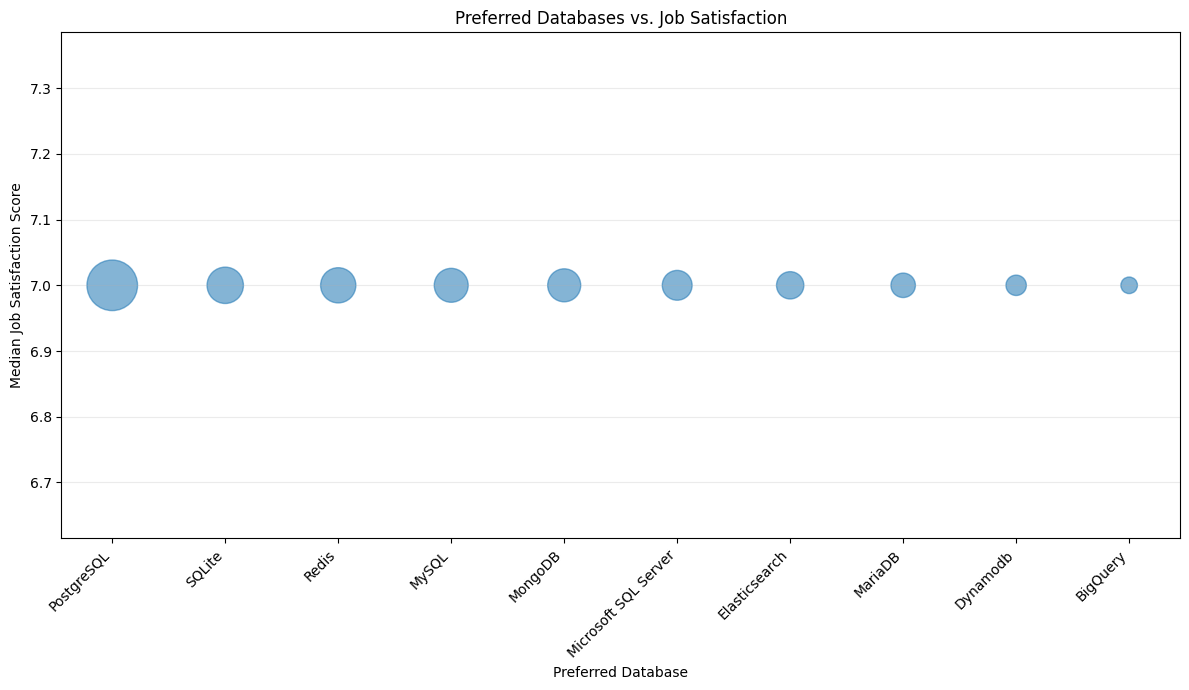

In [11]:
database_order = database_summary.index.tolist()

x_positions = np.arange(
    len(database_order)
)

bubble_sizes = (
    database_summary["Respondents"] / 10
)

plt.figure(figsize=(12, 7))

plt.scatter(
    x_positions,
    database_summary["MedianJobSat"],
    s=bubble_sizes,
    alpha=0.55
)

plt.xticks(
    x_positions,
    database_order,
    rotation=45,
    ha="right"
)

plt.title("Preferred Databases vs. Job Satisfaction")
plt.xlabel("Preferred Database")
plt.ylabel("Median Job Satisfaction Score")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


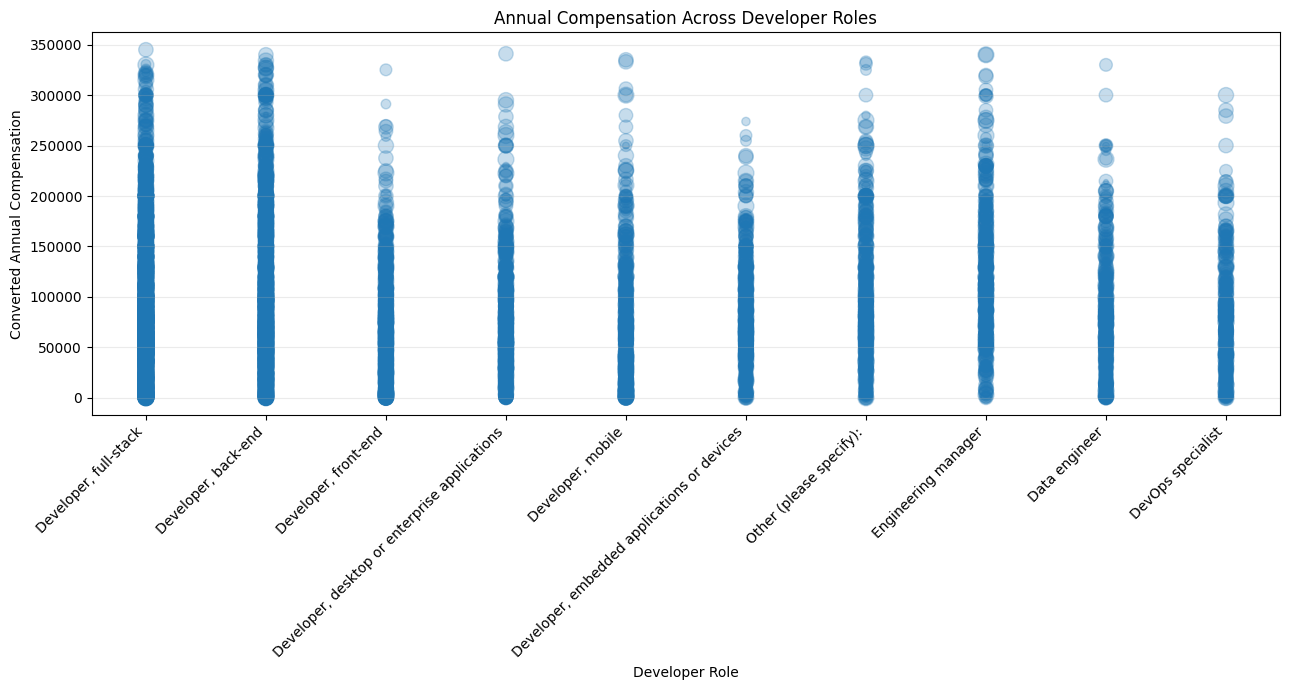

In [12]:
# Task 3.1 - Compensation Across Developer Roles

dev_comp = df[
    ["DevType", "ConvertedCompYearly", "JobSat"]
].copy()

dev_comp["ConvertedCompYearly"] = pd.to_numeric(
    dev_comp["ConvertedCompYearly"],
    errors="coerce"
)

dev_comp["JobSat"] = pd.to_numeric(
    dev_comp["JobSat"],
    errors="coerce"
)

dev_comp = dev_comp.dropna(
    subset=["DevType", "ConvertedCompYearly", "JobSat"]
)

# Split multiple developer roles
dev_comp["DevType"] = dev_comp["DevType"].str.split(";")

dev_comp = dev_comp.explode(
    "DevType",
    ignore_index=True
)

dev_comp["DevType"] = dev_comp["DevType"].str.strip()

# Top 10 developer roles
top_roles = (
    dev_comp["DevType"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

plot_dev = dev_comp[
    dev_comp["DevType"].isin(top_roles)
].copy()

# Limit only the visualization
visual_limit = plot_dev["ConvertedCompYearly"].quantile(0.99)

plot_dev = plot_dev[
    plot_dev["ConvertedCompYearly"] <= visual_limit
]

# Convert roles to numeric X positions
role_positions = {
    role: i for i, role in enumerate(top_roles)
}

x_values = plot_dev["DevType"].map(role_positions)

# Bubble size represents JobSat
bubble_sizes = (plot_dev["JobSat"] + 1) * 12

plt.figure(figsize=(13, 7))

plt.scatter(
    x_values,
    plot_dev["ConvertedCompYearly"],
    s=bubble_sizes,
    alpha=0.25
)

plt.xticks(
    range(len(top_roles)),
    top_roles,
    rotation=45,
    ha="right"
)

plt.title("Annual Compensation Across Developer Roles")
plt.xlabel("Developer Role")
plt.ylabel("Converted Annual Compensation")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [13]:
# Task 3.2 - Collaboration Tools by Age

collab_age = df[
    ["Age", "NEWCollabToolsHaveWorkedWith"]
].copy()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": np.nan
}

collab_age["AgeNumeric"] = collab_age["Age"].map(age_mapping)

collab_age = collab_age.dropna(
    subset=["AgeNumeric", "NEWCollabToolsHaveWorkedWith"]
)

# Split multiple tools
collab_age["Tool"] = (
    collab_age["NEWCollabToolsHaveWorkedWith"]
    .str.split(";")
)

collab_age = collab_age.explode(
    "Tool",
    ignore_index=True
)

collab_age["Tool"] = collab_age["Tool"].str.strip()

# Top 10 collaboration tools
top_tools = (
    collab_age["Tool"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

collab_age = collab_age[
    collab_age["Tool"].isin(top_tools)
]

# Count tool usage by age group
collab_summary = (
    collab_age
    .groupby(["AgeNumeric", "Tool"])
    .size()
    .reset_index(name="Frequency")
)

display(collab_summary.head(20))

,AgeNumeric,Tool,Frequency
0,17.0,Android Studio,479
1,17.0,IntelliJ IDEA,622
2,17.0,Jupyter Notebook/JupyterLab,191
3,17.0,Neovim,522
4,17.0,Notepad++,412
5,17.0,PyCharm,473
6,17.0,Sublime Text,235
7,17.0,Vim,438
8,17.0,Visual Studio,780
9,17.0,Visual Studio Code,1808


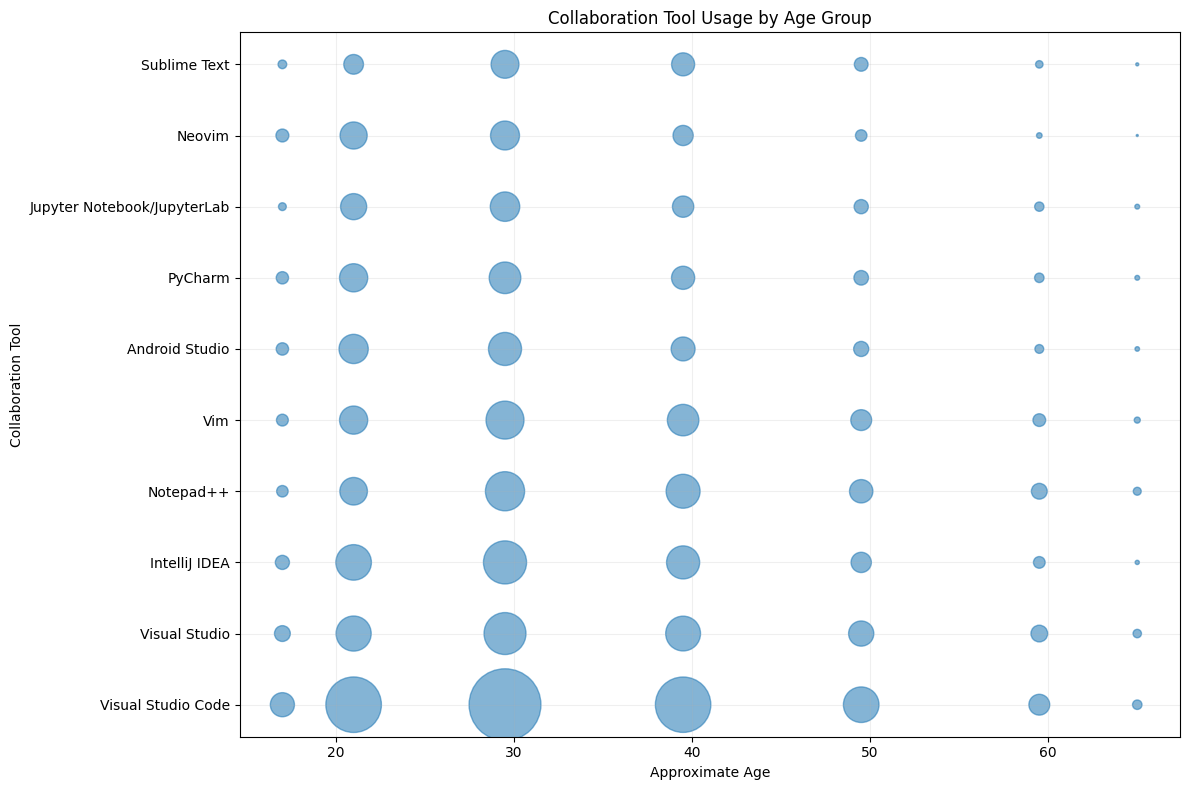

In [14]:
tool_positions = {
    tool: i for i, tool in enumerate(top_tools)
}

y_values = collab_summary["Tool"].map(tool_positions)

# Scale bubble sizes
bubble_sizes = collab_summary["Frequency"] / 6

plt.figure(figsize=(12, 8))

plt.scatter(
    collab_summary["AgeNumeric"],
    y_values,
    s=bubble_sizes,
    alpha=0.55
)

plt.yticks(
    range(len(top_tools)),
    top_tools
)

plt.title("Collaboration Tool Usage by Age Group")
plt.xlabel("Approximate Age")
plt.ylabel("Collaboration Tool")

plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [15]:
# Task 4.1 - Preferred Web Frameworks vs Job Satisfaction

framework_sat = df[
    ["WebframeWantToWorkWith", "JobSat"]
].copy()

# Convert JobSat to numeric
framework_sat["JobSat"] = pd.to_numeric(
    framework_sat["JobSat"],
    errors="coerce"
)

# Keep valid responses
framework_sat = framework_sat.dropna(
    subset=["WebframeWantToWorkWith", "JobSat"]
)

# Split multiple framework selections
framework_sat["Framework"] = (
    framework_sat["WebframeWantToWorkWith"]
    .str.split(";")
)

framework_sat = framework_sat.explode(
    "Framework",
    ignore_index=True
)

framework_sat["Framework"] = (
    framework_sat["Framework"]
    .str.strip()
)

# Top 10 preferred frameworks
top_frameworks = (
    framework_sat["Framework"]
    .value_counts()
    .head(10)
    .index
)

framework_top = framework_sat[
    framework_sat["Framework"].isin(top_frameworks)
]

# Aggregate
framework_summary = (
    framework_top
    .groupby("Framework")
    .agg(
        Respondents=("JobSat", "count"),
        MedianJobSat=("JobSat", "median"),
        MeanJobSat=("JobSat", "mean")
    )
    .sort_values("Respondents", ascending=False)
)

display(framework_summary.round(2))

,Respondents,MedianJobSat,MeanJobSat
Framework,,,
React,8167,7.0,6.95
Node.js,7636,7.0,7.01
Next.js,4322,7.0,6.91
ASP.NET CORE,4199,7.0,7.05
Vue.js,4061,7.0,6.92
Angular,3541,7.0,7.01
Spring Boot,2940,7.0,6.89
Express,2855,7.0,6.88
FastAPI,2731,7.0,6.82


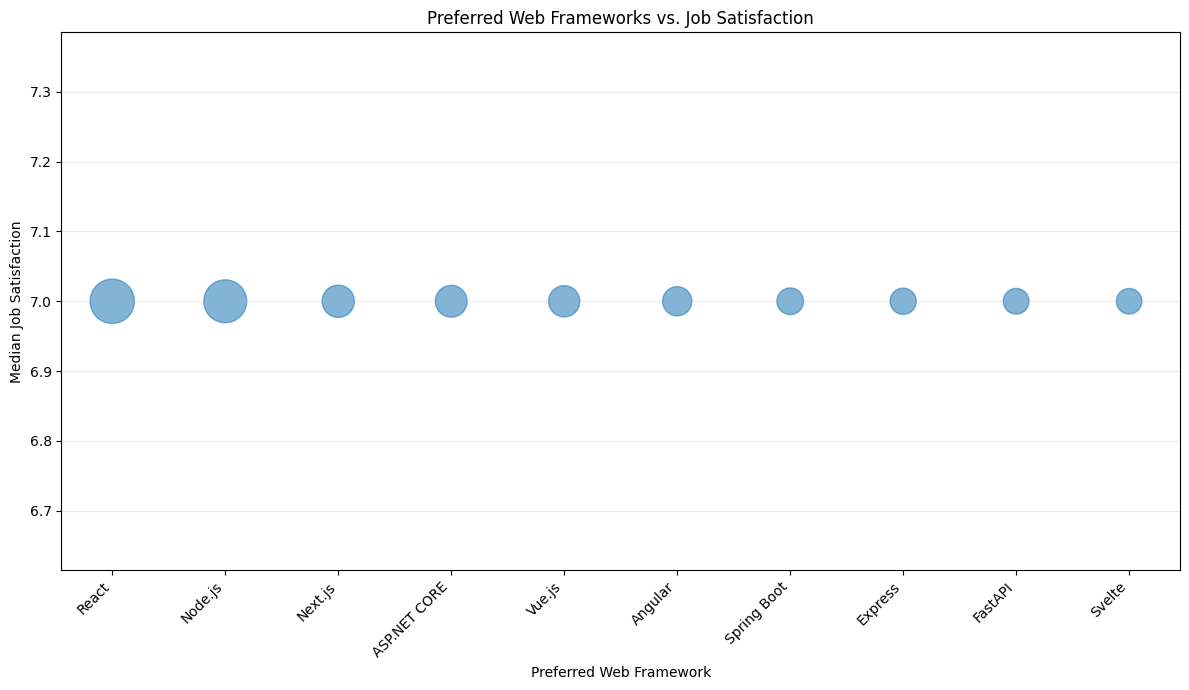

In [16]:
framework_order = framework_summary.index.tolist()
x_positions = np.arange(len(framework_order))

# Scale bubble sizes
bubble_sizes = framework_summary["Respondents"] / 8

plt.figure(figsize=(12, 7))

plt.scatter(
    x_positions,
    framework_summary["MedianJobSat"],
    s=bubble_sizes,
    alpha=0.55
)

plt.xticks(
    x_positions,
    framework_order,
    rotation=45,
    ha="right"
)

plt.title("Preferred Web Frameworks vs. Job Satisfaction")
plt.xlabel("Preferred Web Framework")
plt.ylabel("Median Job Satisfaction")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [17]:
# Task 4.2 - Admired Technologies Across Countries

admired_country = df[
    ["Country", "LanguageAdmired"]
].copy()

admired_country = admired_country.dropna(
    subset=["Country", "LanguageAdmired"]
)

# Split multiple admired languages
admired_country["Language"] = (
    admired_country["LanguageAdmired"]
    .str.split(";")
)

admired_country = admired_country.explode(
    "Language",
    ignore_index=True
)

admired_country["Language"] = (
    admired_country["Language"]
    .str.strip()
)

# Top countries
top_countries = (
    admired_country["Country"]
    .value_counts()
    .head(8)
    .index
)

# Top admired languages
top_languages = (
    admired_country["Language"]
    .value_counts()
    .head(10)
    .index
)

plot_data = admired_country[
    admired_country["Country"].isin(top_countries)
    &
    admired_country["Language"].isin(top_languages)
]

# Count admiration frequency
admired_summary = (
    plot_data
    .groupby(["Country", "Language"])
    .size()
    .reset_index(name="Frequency")
)

display(admired_summary.head(20))

,Country,Language,Frequency
0,Canada,Bash/Shell (all shells),485
1,Canada,C#,392
2,Canada,C++,280
3,Canada,HTML/CSS,671
4,Canada,Java,242
5,Canada,JavaScript,714
6,Canada,Python,741
7,Canada,Rust,260
8,Canada,SQL,700
9,Canada,TypeScript,545


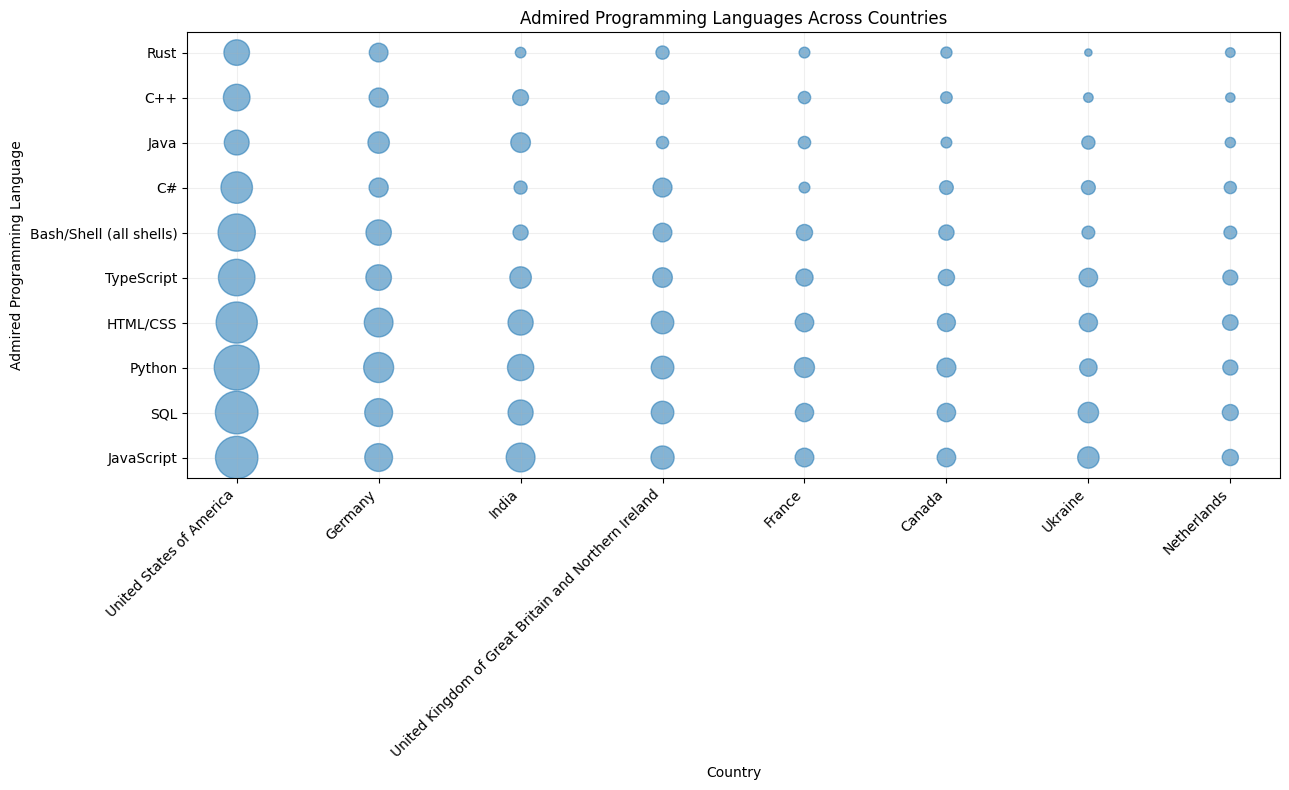

In [18]:
country_order = list(top_countries)
language_order = list(top_languages)

country_positions = {
    country: i
    for i, country in enumerate(country_order)
}

language_positions = {
    language: i
    for i, language in enumerate(language_order)
}

x_values = admired_summary["Country"].map(
    country_positions
)

y_values = admired_summary["Language"].map(
    language_positions
)

# Bubble size = admiration frequency
bubble_sizes = admired_summary["Frequency"] / 4

plt.figure(figsize=(13, 8))

plt.scatter(
    x_values,
    y_values,
    s=bubble_sizes,
    alpha=0.55
)

plt.xticks(
    range(len(country_order)),
    country_order,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(language_order)),
    language_order
)

plt.title("Admired Programming Languages Across Countries")
plt.xlabel("Country")
plt.ylabel("Admired Programming Language")

plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

### Analysis – Admired Programming Languages Across Countries

The bubble plot compares the frequency of admired programming languages across the eight countries with the largest number of valid responses. Bubble size represents how frequently each language was selected within each country.

Across most countries, **JavaScript, SQL, Python, and HTML/CSS** appear among the most admired technologies. These languages consistently show relatively large bubbles, suggesting broad interest across different geographic markets.

The **United States** shows the largest bubbles overall, mainly because it contains the largest number of respondents in the comparison. Therefore, bubble size should be interpreted primarily as frequency rather than as a direct measure of preference intensity between countries.

Germany, India, and the United Kingdom also show substantial interest in several of the same technologies, indicating that the most admired programming languages are relatively consistent across major respondent populations.

Languages such as **Rust, C++, Java, C#, and Bash/Shell** show smaller but still meaningful levels of admiration. Rust is especially noteworthy because, despite having lower absolute frequency than JavaScript or Python, it appears across several countries, suggesting geographically broad developer interest.

Overall, the visualization suggests that technology admiration is not strongly isolated by country. Instead, several languages show widespread international appeal, particularly JavaScript, SQL, Python, and HTML/CSS.

However, because the chart uses **absolute frequencies**, countries with more survey respondents naturally produce larger bubbles. A normalized percentage analysis would be required to determine whether a language is proportionally more admired in one country than another.

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.
